In [1]:
import meep as mp
mp.verbosity(1)

import numpy as np
import matplotlib.pyplot as plt

resolution = 5 #[px/um]

#all dimensions in [um]
lda0 = 1.55
freq0 = 1 / lda0
wvl_min = 1.5
wvl_max = 1.6
wvl_cen = lda0
fmin = 1/wvl_max
fmax = 1/wvl_min
fcen = 1/wvl_cen
df = fmax-fmin
fwidth = df
nfreq = 1

dpml = 0.5 #PML thickness
dsub = 0.2*lda0 #substrate thickness
#dpad = dsub #padding between cell and PML

n_si = 3.45 #silicon refractive index
si = mp.Medium(index = n_si)
n_sio2 = 1.45
sio2 = mp.Medium(index = n_sio2)
n_air = 1.0 #air refractive index
air = mp.Medium(index = n_air)

P = 0.7 #unit cell pitch [um]
unit_cell_pitch = P
h = 0.9 #pillar height [um]

#propgation distances
d0 = 535 #[um]
d1 = 415 #[um]
d2 = d0 #[um]

Nx = 1025 #pixels per dimension
Ny = Nx
nx = (Nx - 1) // 2 #indices without axes (= #512)
ny = (Ny - 1) // 2
dof = 2*((nx + 1)**2) #number of degrees of freedom per metasurface
S = Nx * Ny

size_x = unit_cell_pitch * Nx #actual physical size
size_y = unit_cell_pitch * Ny

xs = np.arange(-Nx//2+1, Nx//2+1) * (size_x / Nx)
ys = np.arange(-Ny//2+1, Ny//2+1) * (size_y / Ny)
print(xs[0],xs[-1])
X, Y = np.meshgrid(xs, ys)
rho = np.sqrt(X**2 + Y**2)

-358.4 358.4


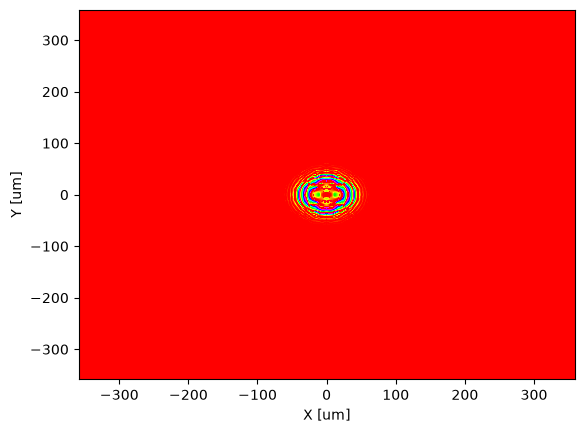

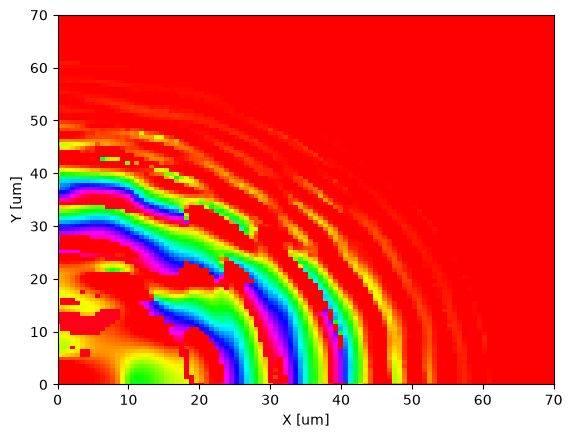

In [ ]:
####################################################
#LOAD PHASE MASK
#___________________________________________________
#load the phase mask data
phase_mask_filename = "../results_sym/optimized_phase_mask_1.npy"
phase_mask = np.load(phase_mask_filename)

fig, ax = plt.subplots()
im = ax.pcolormesh(X, Y, phase_mask, cmap='hsv', shading='auto')
ax.set_xlabel('X [um]')
ax.set_ylabel('Y [um]')
fig.show()

#sim_domain_pixel_size = #full simulation domain (full axis)
sim_domain_size = 140 #[um]

max_sim_radius = 60

X_quadrant = X[nx:, ny:]
xs_quadrant = xs[nx:]
xs_sim = xs[np.abs(xs) <= sim_domain_size/2]
xs_sim_quadrant = xs_quadrant[np.abs(xs_quadrant) <= sim_domain_size/2]

Y_quadrant = Y[nx:, ny:]
ys_quadrant = ys[ny:]
ys_sim = ys[np.abs(ys) <= sim_domain_size/2]
ys_sim_quadrant = ys_quadrant[np.abs(ys_quadrant) <= sim_domain_size/2]

X_sim, Y_sim = np.meshgrid(xs_sim, ys_sim)

phase_mask_quadrant = phase_mask[nx:, ny:]

fig, ax = plt.subplots()
im = ax.pcolormesh(X_quadrant, Y_quadrant, phase_mask_quadrant, cmap='hsv', shading='auto')
ax.set_xlabel('X [um]')
ax.set_ylabel('Y [um]')
ax.set_ybound(0,sim_domain_size/2)
ax.set_xbound(0,sim_domain_size/2)
fig.show()


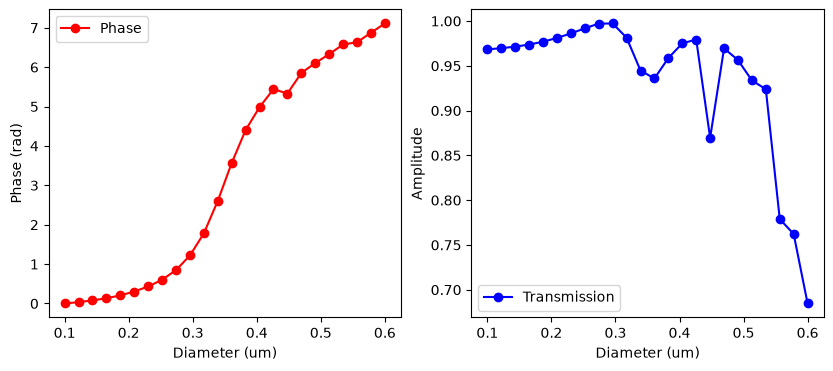

In [3]:
####################################################
#UNIT CELL DATA
#___________________________________________________
#import the unit-cell transmission coefficient data
unit_cell_diameters = np.load("../unit_cell/unit_cell_center_1550_h900nm_res50_wvl_diameters.npy")
unit_cell_mode_phase = np.load("../unit_cell/unit_cell_center_1550_h900nm_res50_wvl_mode_phase.npy")
unit_cell_mode_phase = np.unwrap(unit_cell_mode_phase - unit_cell_mode_phase[0]) #normalize to 0 phase at smallest diameter
unit_cell_mode_tran = np.load("../unit_cell/unit_cell_center_1550_h900nm_res50_wvl_mode_tran.npy")

#make a plot of the unit-cell transmission coefficient
fig, ax = plt.subplots(1, 2, figsize=(10, 4))
ax[0].plot(unit_cell_diameters, unit_cell_mode_phase, 'r-', marker='o', label='Phase')
ax[0].set_xlabel('Diameter (um)')
ax[0].set_ylabel('Phase (rad)')
ax[1].plot(unit_cell_diameters, unit_cell_mode_tran, 'b-', marker='o', label='Transmission')
ax[1].set_xlabel('Diameter (um)')
ax[1].set_ylabel('Amplitude')
ax[0].legend()
ax[1].legend()
plt.show()
####################################################

In [4]:
pillars_geo = []
D_vals = []
theta = unit_cell_mode_phase

for i, x in enumerate(xs_sim_quadrant):
    for j, y in enumerate(ys_sim_quadrant):
        if np.sqrt(x**2 + y**2) > max_sim_radius:
            continue
        else:
            required_diameter = np.interp(phase_mask_quadrant[i,j], theta, unit_cell_diameters)
            #round the required diameter up to three decimal places (nm)
            required_diameter = np.round(required_diameter, 3)
            D_vals.append(required_diameter)
            pillar_geo = mp.Cylinder(
                material=si,
                radius=required_diameter/2, 
                height=h,
                center=mp.Vector3(x, y, h/2), 
                axis=mp.Vector3(0, 0, 1),
            )
            pillars_geo.append(pillar_geo)
print("Number of pillars in simulation domain: ", len(pillars_geo))

Number of pillars in simulation domain:  5859


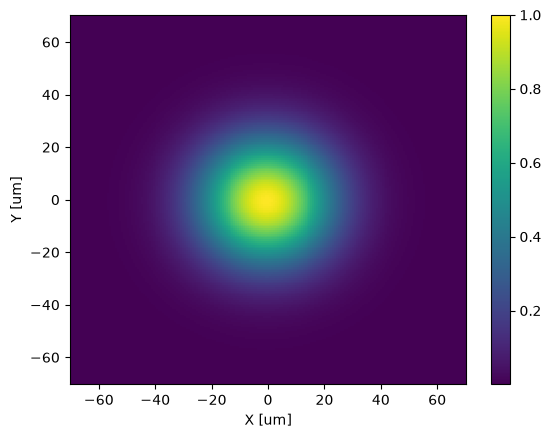

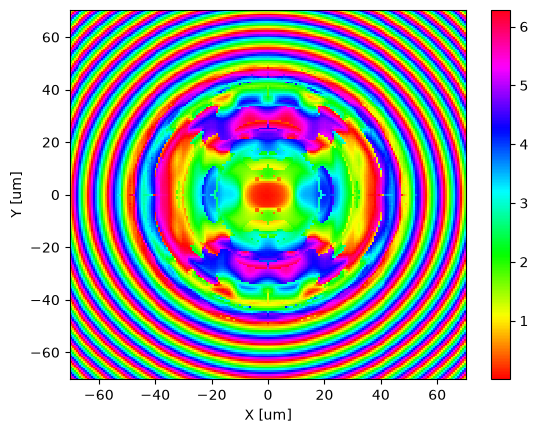

In [5]:
#import the input field (just before MS1)
input_field = np.load("../results_sym/input_field.npy")

mask = (np.abs(X) <= sim_domain_size/2) & (np.abs(Y) <= sim_domain_size/2)

eta_0 = 1 #due to meep's internal normalization
Ex_field_after_MS1 = input_field * np.exp(1j*phase_mask) / np.max(np.abs(input_field))

Ex_field_after_MS1_sim = Ex_field_after_MS1[mask].reshape((len(xs_sim), len(ys_sim)))
Hy_field_after_MS1_sim = Ex_field_after_MS1_sim / eta_0

fig, ax = plt.subplots()
im = ax.pcolormesh(X_sim, Y_sim, np.abs(Ex_field_after_MS1_sim))
ax.set_xlabel('X [um]')
ax.set_ylabel('Y [um]')

fig.colorbar(im, ax=ax)

fig,ax = plt.subplots()
im = ax.pcolormesh(X_sim, Y_sim, (np.angle(Ex_field_after_MS1_sim)+2*np.pi)%(2*np.pi), cmap='hsv', shading='auto')
ax.set_xlabel('X [um]')
ax.set_ylabel('Y [um]')

fig.colorbar(im, ax=ax)

for the equivalence principle, if we want to use the field after MS1
as an actual source, we need to define proper magnetic and electric currents
we assume the input electric field is polarized along the x-axis
and the magnetic field is polarized along the y-axis.
Specifying both electric and magnetic fields is necessary
to obtain a directional source. 

In [6]:
#define the source field dataset
source_position = mp.Vector3(0,0,-0.1)

#the surface currents due to the equivalance principle are:
#Js_x = -Hy_field_after_MS1
#Ms_y = -Ex_field_after_MS1

sources = [
    mp.Source(#electric current
        src=mp.GaussianSource(frequency=freq0, fwidth=fwidth),
        component=mp.Ex,
        center=source_position,
        size=mp.Vector3(sim_domain_size, sim_domain_size, 0),
        amplitude=-1,
        amp_data=Hy_field_after_MS1_sim[:, :, np.newaxis]
    ),

    mp.Source(#magnetic current
        src=mp.GaussianSource(frequency=freq0, fwidth=fwidth),
        component=mp.Hy,
        center=source_position,
        size=mp.Vector3(sim_domain_size, sim_domain_size, 0),
        amplitude=-1,
        amp_data=Ex_field_after_MS1_sim[:, :, np.newaxis]
    ),
]

In [7]:
pml_layers = [mp.PML(dpml)]

Lx = sim_domain_size + 2*dpml
Ly = sim_domain_size + 2*dpml
Lz = 2*dpml + 0.4

cell_size = mp.Vector3(Lx, Ly, Lz)

In [8]:
sim = mp.Simulation(
    resolution=resolution,
    cell_size = cell_size,
    boundary_layers = pml_layers,
    default_material = air,
    sources = sources,
    symmetries = [mp.Mirror(0, phase=-1), mp.Mirror(1, phase=+1)]
)

In [ ]:
#far field points for projection monitor
ff_resolution = 1
ff_plane_size = 19 #[um]

xs_far = np.linspace(-ff_plane_size/2, ff_plane_size/2, ff_resolution * ff_plane_size)
ys_far = np.linspace(-ff_plane_size/2, ff_plane_size/2, ff_resolution * ff_plane_size)

X_far, Y_far = np.meshgrid(xs_far, ys_far)

projection_distance = d1 - np.abs(source_position.z)

near_region_monitor = mp.Near2FarRegion(
    center=mp.Vector3(0, 0, 0),
    size=mp.Vector3(sim_domain_size, sim_domain_size, 0),
)

n2f_obj = sim.add_near2far([freq0], near_region_monitor)

#flux_mon = sim.add_flux(
#        [fcen],
#        mp.FluxRegion(center=mp.Vector3(0,0,0), size=mp.Vector3(sim_domain_size, sim_domain_size, 0))
#    )

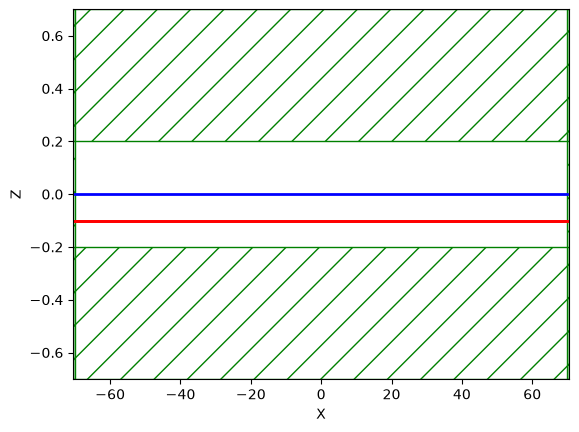

In [10]:
fig, ax = plt.subplots()
plot_xz_plane = mp.Volume(center=mp.Vector3(0,0,0), size=mp.Vector3(Lx, 0, Lz))
sim.plot2D(ax=ax,output_plane=plot_xz_plane)
ax.set_aspect('auto')

In [11]:
obs_point = mp.Vector3(0,0,0)
stop_cond = mp.stop_when_fields_decayed(50, mp.Ez, obs_point, 1e-9)

sim.run(until_after_sources=stop_cond)

-----------
Initializing structure...
Padding x to even number of grid points.
Padding y to even number of grid points.
Halving computational cell along direction x
Halving computational cell along direction y
time for choose_chunkdivision = 0.002388 s
Working in 3D dimensions.
Computational cell is 141 x 141 x 1.4 with resolution 5
time for set_epsilon = 1.77537 s
-----------
on time step 1 (time=0.1), 6.54313 s/step
on time step 143 (time=14.3), 0.0282719 s/step
on time step 280 (time=28), 0.0292696 s/step
on time step 417 (time=41.7), 0.0292706 s/step
field decay(t = 50.1): 5.1928038062217734e-11 / 5.1928038062217734e-11 = 1.0
on time step 554 (time=55.4), 0.0292244 s/step
on time step 695 (time=69.5), 0.0284944 s/step
on time step 839 (time=83.9), 0.027918 s/step
on time step 979 (time=97.9), 0.0287308 s/step
field decay(t = 100.2): 1.2208801300100384e-07 / 1.2208801300100384e-07 = 1.0
on time step 1120 (time=112), 0.0286236 s/step
on time step 1258 (time=125.8), 0.0290669 s/step
o

In [ ]:

far_plane = mp.Volume(
    center=mp.Vector3(0, 0, projection_distance),
    size=mp.Vector3(ff_plane_size, ff_plane_size, 0)
)

ff_data = sim.get_farfields(n2f_obj, 1, where=far_plane)

ff_Ex = ff_data['Ex']

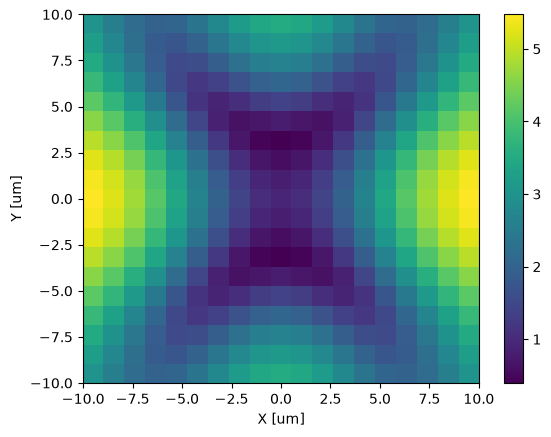

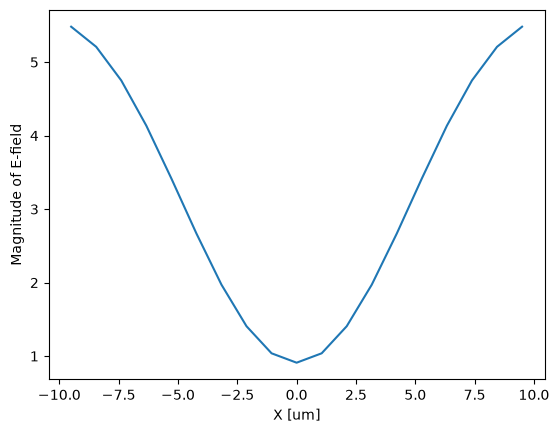

In [19]:
fig, ax = plt.subplots()
im = ax.pcolormesh(X_far, Y_far, np.abs(ff_Ex), cmap='viridis', shading='auto')
ax.set_xlabel('X [um]')
ax.set_ylabel('Y [um]')
fig.colorbar(im, ax=ax)
fig.show()
fig.savefig("magnitude_field_before_MS2.pdf")

#make a line plot that is a slice along the y=0 axis
fig, az = plt.subplots()
im = az.plot(xs_far, np.abs(ff_Ex[ff_resolution * ff_plane_size//2, :]))
az.set_xlabel('X [um]')
az.set_ylabel('Magnitude of E-field')
fig.show()